Введите радиус щётки (например 0.1):  0.03



=== Brush Path Points Report ===
Brush radius: 0.03
Section boundaries: Left (x ≤ 0.5), Middle (0.5 < x < 0.8), Right (x ≥ 0.8)

Section: Middle
Polygon: 1
Points count: 12
Points: (0.5000,0.2667) (0.5000,0.3722) (0.5400,0.2405) (0.5400,0.4490) (0.5800,0.2028) (0.5800,0.4678) (0.6200,0.1824) (0.6200,0.4518) (0.6600,0.1708) (0.6600,0.4319) (0.7000,0.3139) (0.7000,0.3905)

Section: Left
Polygon: 3
Points count: 8
Points: (0.2817,0.4269) (0.2817,0.5695) (0.3217,0.3911) (0.3217,0.5524) (0.3617,0.3864) (0.3617,0.5409) (0.4017,0.4248) (0.4017,0.5112)

Section: Left
Polygon: 4
Points count: 12
Points: (0.2359,0.0005) (0.2359,0.1628) (0.2759,0.0006) (0.2759,0.2585) (0.3159,0.0006) (0.3159,0.0910) (0.3559,0.0007) (0.3559,0.0430) (0.3959,0.0008) (0.3959,0.0481) (0.4359,0.0009) (0.4359,0.0243)

Section: Middle
Polygon: 6
Points count: 6
Points: (0.5000,0.0000) (0.5000,0.1562) (0.5400,0.0000) (0.5400,0.1792) (0.5800,0.0190) (0.5800,0.1623)

Section: Middle
Polygon: 7
Points count: 6
Points: (0.70

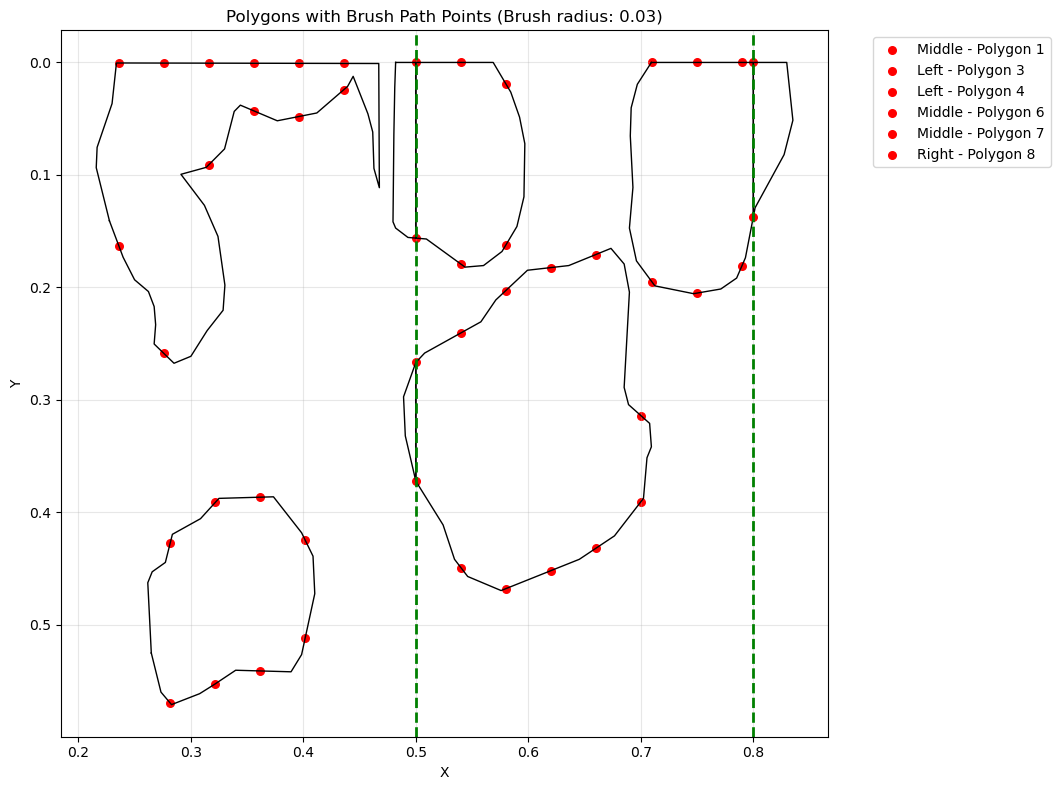

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, MultiPolygon
from shapely.ops import split

def parse_data(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    polygons = []
    current_polygon = []

    for line in lines:
        data = line.strip().split(" ")[1:]  # Удаляем первый элемент
        if not data:  # Если строка пустая, пропускаем
            continue
        
        coords = list(map(float, data))
        current_polygon.extend(zip(coords[::2], coords[1::2]))  # Пара (x, y)

        if line.startswith('0'):
            if current_polygon:
                polygons.append(Polygon(current_polygon))
                current_polygon = []

    if current_polygon:
        polygons.append(Polygon(current_polygon))

    return polygons

def create_halses(polygon, spacing):
    minx, miny, maxx, maxy = polygon.bounds
    halses = []
    x = minx
    while x <= maxx:
        line = LineString([(x, miny), (x, maxy)])
        intersection = polygon.intersection(line)
        if intersection.is_empty:
            x += spacing
            continue
        if intersection.geom_type == 'MultiLineString':
            for geom in intersection.geoms:
                halses.append(geom)
        elif intersection.geom_type == 'LineString':
            halses.append(intersection)
        x += spacing
    return halses

def split_polygon_with_lines(polygon):
    split_lines = [
        LineString([(0.5, polygon.bounds[1]), (0.5, polygon.bounds[3])]),
        LineString([(0.8, polygon.bounds[1]), (0.8, polygon.bounds[3])])
    ]
    
    result = [polygon]
    
    for split_line in split_lines:
        temp = []
        for geom in result:
            if geom.geom_type not in ['Polygon', 'MultiPolygon']:
                continue
                
            if geom.intersects(split_line):
                try:
                    parts = split(geom, split_line)
                    if parts.geom_type == 'MultiPolygon':
                        temp.extend(parts.geoms)
                    elif parts.geom_type == 'GeometryCollection':
                        for part in parts.geoms:
                            if part.geom_type == 'Polygon':
                                temp.append(part)
                    else:
                        temp.append(parts)
                except:
                    temp.append(geom)
            else:
                temp.append(geom)
        result = temp
    
    return [geom for geom in result if geom.geom_type == 'Polygon' and not geom.is_empty]

def determine_section(polygon):
    minx, _, maxx, _ = polygon.bounds
    if maxx <= 0.5:
        return "Left"
    elif minx >= 0.8:
        return "Right"
    else:
        return "Middle"

def filter_points_by_brush_size(points, brush_radius, polygon_width):
    if len(points) <= 2:
        return points
    
    # Если щётка больше ширины полигона - берем центральные точки
    if brush_radius >= polygon_width:
        middle_idx = len(points) // 2
        if len(points) % 2 == 0:  # Четное количество точек
            return [points[middle_idx-1], points[middle_idx]]
        else:  # Нечетное количество точек
            return [points[middle_idx]]
    
    # Разделяем точки на четные и нечетные позиции
    even_points = points[::2]  # Четные позиции (0, 2, 4...)
    odd_points = points[1::2]  # Нечетные позиции (1, 3, 5...)
    
    # Функция для фильтрации последовательности точек
    def filter_sequence(sequence):
        if not sequence:
            return []
        filtered = [sequence[0]]
        last_kept = sequence[0]
        for point in sequence[1:]:
            if abs(point[0] - last_kept[0]) >= brush_radius:
                filtered.append(point)
                last_kept = point
        return filtered
    
    # Фильтруем отдельно четные и нечетные точки
    filtered_even = filter_sequence(even_points)
    filtered_odd = filter_sequence(odd_points)
    
    # Объединяем результаты, сохраняя исходный порядок
    result = []
    for i in range(max(len(filtered_even), len(filtered_odd))):
        if i < len(filtered_even):
            result.append(filtered_even[i])
        if i < len(filtered_odd):
            result.append(filtered_odd[i])
    
    return result

def process_polygons(polygons, spacing, brush_radius):
    all_new_points = []
    split_polygons = []
    
    for polygon in polygons:
        split_polygons.extend(split_polygon_with_lines(polygon))
    
    for polygon_idx, polygon in enumerate(split_polygons):
        halses = create_halses(polygon, spacing)
        all_points = []
        
        for line in halses:
            x_coords = line.xy[0]
            y_coords = line.xy[1]
            all_points.extend(zip(x_coords, y_coords))
        
        if len(all_points) <= 2:
            continue
            
        # Сортируем точки по X (слева направо)
        all_points.sort(key=lambda p: p[0])
        
        # Получаем ширину полигона
        minx, _, maxx, _ = polygon.bounds
        polygon_width = maxx - minx
        
        # Фильтруем точки по радиусу щётки
        filtered_points = filter_points_by_brush_size(all_points, brush_radius, polygon_width)
        
        section = determine_section(polygon)
        all_new_points.append((section, polygon_idx + 1, filtered_points))
    
    return split_polygons, all_new_points

def plot_results(polygons, spacing, new_points_data, brush_radius):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Рисуем полигоны
    for polygon in polygons:
        if polygon.geom_type == 'Polygon' and not polygon.is_empty:
            x, y = polygon.exterior.xy
            ax.plot(x, y, color='black', linewidth=1)
    
    # Разделительные линии
    ax.axvline(x=0.5, color='green', linestyle='--', linewidth=2)
    ax.axvline(x=0.8, color='green', linestyle='--', linewidth=2)
    
    # Рисуем отфильтрованные точки
    for section, poly_idx, points in new_points_data:
        if points:
            x, y = zip(*points)
            ax.scatter(x, y, color='red', s=30, label=f'{section} - Polygon {poly_idx}')
    
    ax.set_aspect('equal')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Polygons with Brush Path Points (Brush radius: {brush_radius})')
    plt.grid(True, alpha=0.3)
    plt.gca().invert_yaxis()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Основной код
file_path = '.ipynb_checkpoints/PrujectNN/example_lables/f1_2759_jpg.rf.a158e3f8e17acb7e2c37fb5070ed1431.txt'
polygons = parse_data(file_path)

# Ввод радиуса щётки
brush_radius = float(input("Введите радиус щётки (например 0.1): "))
spacing = 0.02

# Обработка полигонов
split_polygons, new_points_data = process_polygons(polygons, spacing, brush_radius)

# Вывод результатов
print("\n=== Brush Path Points Report ===")
print(f"Brush radius: {brush_radius}")
print("Section boundaries: Left (x ≤ 0.5), Middle (0.5 < x < 0.8), Right (x ≥ 0.8)\n")

if not new_points_data:
    print("No polygons with enough points found!")
else:
    for section, poly_idx, points in new_points_data:
        print(f"Section: {section}")
        print(f"Polygon: {poly_idx}")
        print(f"Points count: {len(points)}")
        print("Points:", " ".join(f"({x:.4f},{y:.4f})" for x, y in points))
        print()

# Визуализация
if split_polygons:
    plot_results(split_polygons, spacing, new_points_data, brush_radius)
else:
    print("No polygons to display!")

Creating colored polygons plot...


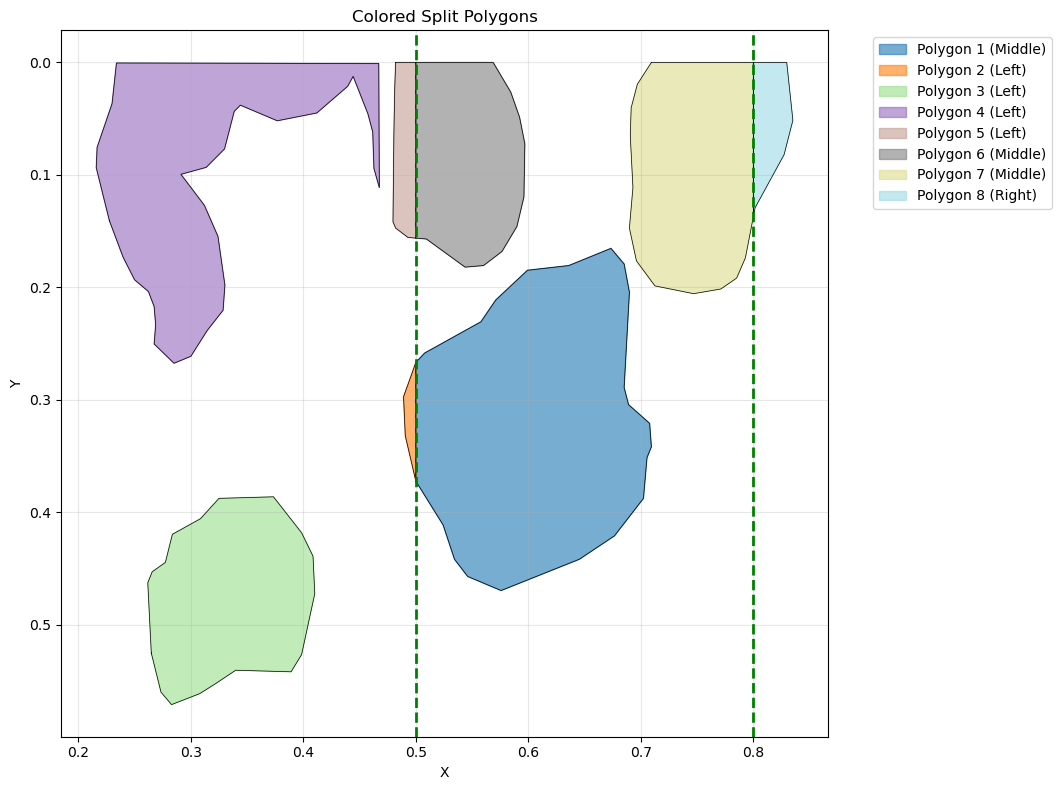

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, MultiPolygon
from shapely.ops import split
from matplotlib.colors import ListedColormap

def parse_data(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    polygons = []
    current_polygon = []

    for line in lines:
        data = line.strip().split(" ")[1:]  # Удаляем первый элемент
        if not data:  # Если строка пустая, пропускаем
            continue
        
        coords = list(map(float, data))
        current_polygon.extend(zip(coords[::2], coords[1::2]))  # Пара (x, y)

        if line.startswith('0'):
            if current_polygon:
                polygons.append(Polygon(current_polygon))
                current_polygon = []

    if current_polygon:
        polygons.append(Polygon(current_polygon))

    return polygons

def create_halses(polygon, spacing):
    minx, miny, maxx, maxy = polygon.bounds
    halses = []
    x = minx
    while x <= maxx:
        line = LineString([(x, miny), (x, maxy)])
        intersection = polygon.intersection(line)
        if intersection.is_empty:
            x += spacing
            continue
        if intersection.geom_type == 'MultiLineString':
            for geom in intersection.geoms:
                halses.append(geom)
        elif intersection.geom_type == 'LineString':
            halses.append(intersection)
        x += spacing
    return halses

def split_polygon_with_lines(polygon):
    split_lines = [
        LineString([(0.5, polygon.bounds[1]), (0.5, polygon.bounds[3])]),
        LineString([(0.8, polygon.bounds[1]), (0.8, polygon.bounds[3])])
    ]
    
    result = [polygon]
    
    for split_line in split_lines:
        temp = []
        for geom in result:
            if geom.geom_type not in ['Polygon', 'MultiPolygon']:
                continue
                
            if geom.intersects(split_line):
                try:
                    parts = split(geom, split_line)
                    if parts.geom_type == 'MultiPolygon':
                        temp.extend(parts.geoms)
                    elif parts.geom_type == 'GeometryCollection':
                        for part in parts.geoms:
                            if part.geom_type == 'Polygon':
                                temp.append(part)
                    else:
                        temp.append(parts)
                except:
                    temp.append(geom)
            else:
                temp.append(geom)
        result = temp
    
    # Фильтруем только непустые полигоны
    return [geom for geom in result if geom.geom_type == 'Polygon' and not geom.is_empty]

def determine_section(polygon):
    minx, _, maxx, _ = polygon.bounds
    if maxx <= 0.5:
        return "Left"
    elif minx >= 0.8:
        return "Right"
    else:
        return "Middle"

def plot_colored_polygons(polygons):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Создаем цветовую карту
    colors = plt.cm.tab20(np.linspace(0, 1, len(polygons)))
    
    for i, polygon in enumerate(polygons):
        x, y = polygon.exterior.xy
        ax.fill(x, y, color=colors[i], alpha=0.6, label=f'Polygon {i+1} ({determine_section(polygon)})')
        ax.plot(x, y, color='black', linewidth=0.5)
    
    # Разделительные линии
    ax.axvline(x=0.5, color='green', linestyle='--', linewidth=2)
    ax.axvline(x=0.8, color='green', linestyle='--', linewidth=2)
    
    ax.set_aspect('equal')
    plt.title('Colored Split Polygons')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, alpha=0.3)
    plt.gca().invert_yaxis()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Основной код
file_path = '.ipynb_checkpoints/PrujectNN/example_lables/f1_2759_jpg.rf.a158e3f8e17acb7e2c37fb5070ed1431.txt'
polygons = parse_data(file_path)

# Разделяем полигоны
split_polygons = []
for polygon in polygons:
    split_polygons.extend(split_polygon_with_lines(polygon))

# Создаем график с цветными полигонами
if split_polygons:
    print("Creating colored polygons plot...")
    plot_colored_polygons(split_polygons)
else:
    print("No polygons to display!")